In [ ]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt


Loaded lastframe_8/run_001/layer1.pt: layer=1, head=8, frames=72
Attention diagnostics
  raw: sum=64.9549, min=-4.87891, max=9.75 at frame 71
  local softmax window: frames 51-71; window sum=1 (normalization is local, not over all 72 frames), min=9.90653e-07, max=0.873324 at frame 71
  raw frames 60-71:
    [-0.573242 -3.480469 -3.005859  0.524414  3.810547  4.167969  2.052734
 -0.302246 -0.82373   2.929688  7.664062  9.75    ]
  local softmax frames 51-71:
    [1.233440e-03 6.437566e-03 5.964525e-04 1.013307e-05 9.906529e-07
 4.457175e-06 1.549873e-04 1.844394e-03 8.184447e-04 2.869778e-05
 1.567675e-06 2.519858e-06 8.601108e-05 2.299872e-03 3.287987e-03
 3.965477e-04 3.763054e-05 2.233895e-05 9.531283e-04 1.084587e-01
 8.733242e-01]
  full softmax plot vector NaN outside frames 51-71; nansum=1
  top raw frames:
    frame 71: 9.75
    frame 70: 7.66406
    frame  2: 5.15234
    frame 33: 4.92578
    frame 52: 4.83984
    frame  8: 4.59766
    frame 14: 4.58984
    frame 40: 4.54688
  

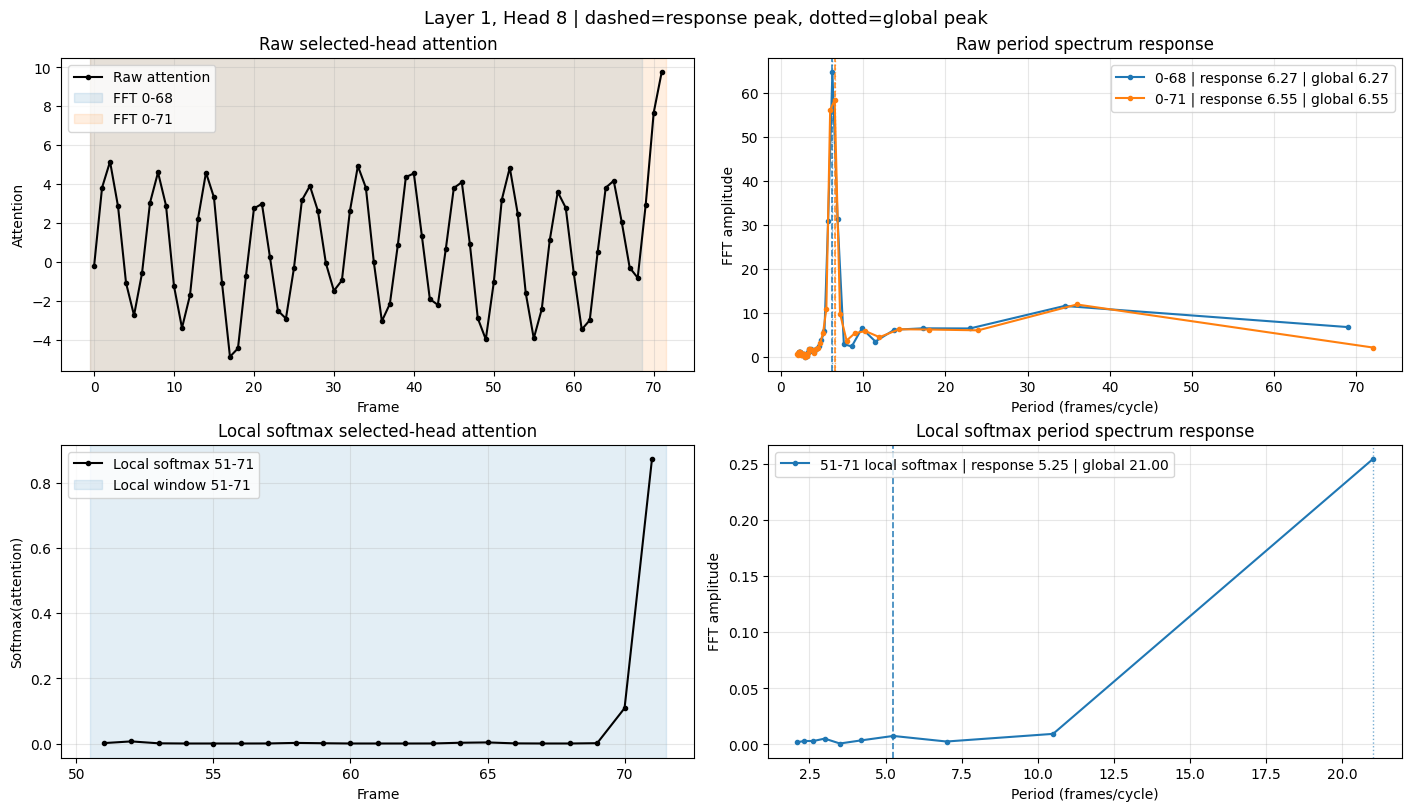

In [ ]:
ATTN_DIR = Path("lastframe_8/run_001")
LAYER = 1
HEAD = 8

# End is exclusive: 0:69 means frames 0-68; None means through the last frame.
FFT_RANGES = [
    {"label": "0-68", "start": 0, "end": 69},
    {"label": "0-71", "start": 0, "end": None},
]

SOFTMAX_WINDOW_START = 51
SOFTMAX_WINDOW_END = 72
SOFTMAX_WINDOW_LABEL = "51-71"
SOFTMAX_FFT_RANGES = [
    {"label": f"{SOFTMAX_WINDOW_LABEL} local softmax", "start": 0, "end": None},
]

# Period display range in frames/cycle. Zero frequency is excluded from period plots.
PERIOD_MIN = 2.0
PERIOD_MAX = None

# Response-period selection excludes low-frequency envelope peaks by default.
RESPONSE_PERIOD_MIN = 4.0
RESPONSE_PERIOD_MAX = 18.0
MIN_RESPONSE_CYCLES = 3.0

REMOVE_DC = True
APPLY_WINDOW = True
SOFTMAX_TEMPERATURE = 1.0

attention, frame_idx, attn_path = load_attention(ATTN_DIR, LAYER, HEAD)
softmax_attention, softmax_window = local_softmax_1d(
    attention,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_END,
    temperature=SOFTMAX_TEMPERATURE,
)

raw_results = analyze_fft_ranges(attention, FFT_RANGES)
softmax_results = analyze_fft_ranges(softmax_window, SOFTMAX_FFT_RANGES)

print(f"Loaded {attn_path}: layer={LAYER}, head={HEAD}, frames={attention.size}")
print_attention_diagnostics(
    attention,
    softmax_attention,
    softmax_window,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_LABEL,
)
print_results("Raw attention", raw_results)
print_results("Local softmax attention", softmax_results)

plot_attention_and_spectra(
    frame_idx,
    attention,
    softmax_attention,
    raw_results,
    softmax_results,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_END,
    SOFTMAX_WINDOW_LABEL,
)

In [ ]:
def load_attention(attn_dir, layer, head):
    attn_path = attn_dir / f"layer{layer}.pt"
    payload = torch.load(attn_path, map_location="cpu", weights_only=False)

    per_head = payload["last_frame_attention_per_head"]
    if per_head.ndim != 2:
        raise ValueError(f"Expected per-head attention to be 2D, got shape {tuple(per_head.shape)}")
    if not 0 <= head < per_head.shape[0]:
        raise IndexError(f"HEAD={head} is out of range for {per_head.shape[0]} heads")

    attention = per_head[head].detach().cpu().float().numpy()
    if attention.ndim != 1:
        raise ValueError(f"Expected selected head attention to be 1D, got shape {attention.shape}")

    frame_idx = np.arange(attention.shape[0])
    return attention, frame_idx, attn_path


In [ ]:
def normalize_range(start, end, size):
    start = 0 if start is None else start
    end = size if end is None else end
    start_norm = start if start >= 0 else size + start
    end_norm = end if end >= 0 else size + end
    if start_norm < 0 or end_norm > size or start_norm >= end_norm:
        raise ValueError(f"Invalid FFT range {start}:{end} for {size} frames")
    return start, end, start_norm, end_norm


In [ ]:
def softmax_1d(values, temperature=1.0):
    if temperature <= 0:
        raise ValueError("SOFTMAX_TEMPERATURE must be positive")
    scaled = values.astype(np.float64) / temperature
    scaled = scaled - np.max(scaled)
    exp_values = np.exp(scaled)
    return exp_values / exp_values.sum()


def local_softmax_1d(values, start, end, temperature=1.0):
    _, _, start_norm, end_norm = normalize_range(start, end, values.size)
    softmax_window = softmax_1d(values[start_norm:end_norm], temperature=temperature)
    softmax_full = np.full(values.shape, np.nan, dtype=np.float64)
    softmax_full[start_norm:end_norm] = softmax_window
    return softmax_full, softmax_window


In [ ]:
def preprocess_signal(sequence, remove_dc=True, apply_window=True):
    if sequence.ndim != 1 or sequence.size < 2:
        raise ValueError(f"FFT input must be 1D with at least 2 frames, got shape {sequence.shape}")

    signal = sequence.astype(np.float64, copy=True)
    if remove_dc:
        signal = signal - signal.mean()
    if apply_window:
        signal = signal * np.hanning(signal.size)
    return signal


In [ ]:
def compute_period_spectrum(
    sequence,
    period_min=2.0,
    period_max=None,
    response_period_min=4.0,
    response_period_max=18.0,
    min_response_cycles=3.0,
    remove_dc=True,
    apply_window=True,
):
    signal = preprocess_signal(sequence, remove_dc=remove_dc, apply_window=apply_window)
    freq = np.fft.rfftfreq(signal.size, d=1.0)
    amplitude = np.abs(np.fft.rfft(signal))
    nonzero_mask = freq > 0
    if not np.any(nonzero_mask):
        raise ValueError("FFT produced no nonzero frequency bins")

    period = 1.0 / freq[nonzero_mask]
    period_amplitude = amplitude[nonzero_mask]
    order = np.argsort(period)
    period = period[order]
    period_amplitude = period_amplitude[order]

    display_mask = np.ones_like(period, dtype=bool)
    if period_min is not None:
        display_mask &= period >= period_min
    if period_max is not None:
        display_mask &= period <= period_max
    if not np.any(display_mask):
        raise ValueError(f"Period display range [{period_min}, {period_max}] contains no FFT bins")

    global_idx = int(np.argmax(period_amplitude))
    cycles = signal.size / period
    response_mask = np.ones_like(period, dtype=bool)
    if response_period_min is not None:
        response_mask &= period >= response_period_min
    if response_period_max is not None:
        response_mask &= period <= response_period_max
    if min_response_cycles is not None:
        response_mask &= cycles >= min_response_cycles
    if np.any(response_mask):
        response_candidates = np.flatnonzero(response_mask)
        response_idx = int(response_candidates[np.argmax(period_amplitude[response_mask])])
    else:
        response_idx = None

    return {
        "period": period,
        "period_amplitude": period_amplitude,
        "display_mask": display_mask,
        "response_mask": response_mask,
        "global_period": period[global_idx],
        "global_freq": 1.0 / period[global_idx],
        "global_amp": period_amplitude[global_idx],
        "response_period": np.nan if response_idx is None else period[response_idx],
        "response_freq": np.nan if response_idx is None else 1.0 / period[response_idx],
        "response_amp": np.nan if response_idx is None else period_amplitude[response_idx],
        "signal_size": signal.size,
    }


In [ ]:
def analyze_fft_ranges(values, fft_ranges):
    results = []
    for cfg in fft_ranges:
        start, end, start_norm, end_norm = normalize_range(cfg.get("start"), cfg.get("end"), values.size)
        spectrum = compute_period_spectrum(
            values[start:end],
            period_min=PERIOD_MIN,
            period_max=PERIOD_MAX,
            response_period_min=RESPONSE_PERIOD_MIN,
            response_period_max=RESPONSE_PERIOD_MAX,
            min_response_cycles=MIN_RESPONSE_CYCLES,
            remove_dc=REMOVE_DC,
            apply_window=APPLY_WINDOW,
        )
        results.append({**cfg, **spectrum, "start_norm": start_norm, "end_norm": end_norm})
    return results


In [ ]:
def print_results(title, results):
    print(title)
    for result in results:
        inclusive_end = result["end_norm"] - 1
        print(
            f"  {result['label']}: frames {result['start_norm']}-{inclusive_end} "
            f"({result['signal_size']} frames), "
            f"global={result['global_period']:.3f} frames "
            f"(amp={result['global_amp']:.6g}), "
            f"response={result['response_period']:.3f} frames "
            f"(amp={result['response_amp']:.6g})"
        )


In [ ]:
def print_attention_diagnostics(
    raw_attention,
    softmax_full,
    softmax_window,
    softmax_window_start,
    softmax_window_label,
    tail_start=60,
    top_k=10,
):
    raw_top = np.argsort(raw_attention)[-top_k:][::-1]
    softmax_top = np.argsort(softmax_window)[-top_k:][::-1]
    softmax_window_end = softmax_window_start + softmax_window.size

    print("Attention diagnostics")
    print(
        f"  raw: sum={raw_attention.sum():.6g}, min={raw_attention.min():.6g}, "
        f"max={raw_attention.max():.6g} at frame {int(np.argmax(raw_attention))}"
    )
    print(
        f"  local softmax window: frames {softmax_window_label}; "
        f"window sum={softmax_window.sum():.6g} (normalization is local, not over all {raw_attention.size} frames), "
        f"min={softmax_window.min():.6g}, max={softmax_window.max():.6g} "
        f"at frame {int(softmax_window_start + np.argmax(softmax_window))}"
    )
    print(f"  raw frames {tail_start}-{raw_attention.size - 1}:")
    print("   ", np.array2string(raw_attention[tail_start:], precision=6, suppress_small=False))
    print(f"  local softmax frames {softmax_window_start}-{softmax_window_end - 1}:")
    print("   ", np.array2string(softmax_window, precision=6, suppress_small=False))
    print(f"  full softmax plot vector NaN outside frames {softmax_window_label}; nansum={np.nansum(softmax_full):.6g}")
    print("  top raw frames:")
    for idx in raw_top:
        print(f"    frame {int(idx):2d}: {raw_attention[idx]:.6g}")
    print("  top local softmax frames:")
    for idx in softmax_top:
        frame = int(softmax_window_start + idx)
        print(f"    frame {frame:2d}: {softmax_window[idx]:.6g}")


In [ ]:
def plot_attention_and_spectra(
    frame_idx,
    raw_attention,
    softmax_attention,
    raw_results,
    softmax_results,
    softmax_window_start,
    softmax_window_end,
    softmax_window_label,
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    ax_raw_time, ax_raw_period = axes[0]
    ax_softmax_time, ax_softmax_period = axes[1]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax_raw_time.plot(frame_idx, raw_attention, marker="o", linewidth=1.5, markersize=3, color="black", label="Raw attention")
    ax_softmax_time.plot(frame_idx, softmax_attention, marker="o", linewidth=1.5, markersize=3, color="black", label=f"Local softmax {softmax_window_label}")

    for idx, result in enumerate(raw_results):
        color = colors[idx % len(colors)]
        ax_raw_time.axvspan(
            result["start_norm"] - 0.5,
            result["end_norm"] - 0.5,
            color=color,
            alpha=0.12,
            label=f"FFT {result['label']}",
        )

    ax_softmax_time.axvspan(
        softmax_window_start - 0.5,
        softmax_window_end - 0.5,
        color=colors[0],
        alpha=0.12,
        label=f"Local window {softmax_window_label}",
    )

    for ax, ylabel, title in [
        (ax_raw_time, "Attention", "Raw selected-head attention"),
        (ax_softmax_time, "Softmax(attention)", "Local softmax selected-head attention"),
    ]:
        ax.set_xlabel("Frame")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    for ax, results, title in [
        (ax_raw_period, raw_results, "Raw period spectrum response"),
        (ax_softmax_period, softmax_results, "Local softmax period spectrum response"),
    ]:
        for idx, result in enumerate(results):
            color = colors[idx % len(colors)]
            mask = result["display_mask"]
            ax.plot(
                result["period"][mask],
                result["period_amplitude"][mask],
                marker="o",
                linewidth=1.5,
                markersize=3,
                color=color,
                label=f"{result['label']} | response {result['response_period']:.2f} | global {result['global_period']:.2f}",
            )
            if np.isfinite(result["global_period"]):
                ax.axvline(result["global_period"], color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            if np.isfinite(result["response_period"]):
                ax.axvline(result["response_period"], color=color, linestyle="--", linewidth=1.2, alpha=0.9)

        ax.set_xlabel("Period (frames/cycle)")
        ax.set_ylabel("FFT amplitude")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    fig.suptitle(f"Layer {LAYER}, Head {HEAD} | dashed=response peak, dotted=global peak", fontsize=13)
    plt.show()


Loaded lastframe_8/run_001/layer1.pt: layer=1, head=8, frames=72
Attention diagnostics
  raw: sum=64.9549, min=-4.87891, max=9.75 at frame 71
  local softmax window: frames 51-71; window sum=1 (normalization is local, not over all 72 frames), min=9.90653e-07, max=0.873324 at frame 71
  raw frames 60-71:
    [-0.573242 -3.480469 -3.005859  0.524414  3.810547  4.167969  2.052734
 -0.302246 -0.82373   2.929688  7.664062  9.75    ]
  local softmax frames 51-71:
    [1.233440e-03 6.437566e-03 5.964525e-04 1.013307e-05 9.906529e-07
 4.457175e-06 1.549873e-04 1.844394e-03 8.184447e-04 2.869778e-05
 1.567675e-06 2.519858e-06 8.601108e-05 2.299872e-03 3.287987e-03
 3.965477e-04 3.763054e-05 2.233895e-05 9.531283e-04 1.084587e-01
 8.733242e-01]
  full softmax plot vector NaN outside frames 51-71; nansum=1
  top raw frames:
    frame 71: 9.75
    frame 70: 7.66406
    frame  2: 5.15234
    frame 33: 4.92578
    frame 52: 4.83984
    frame  8: 4.59766
    frame 14: 4.58984
    frame 40: 4.54688
  

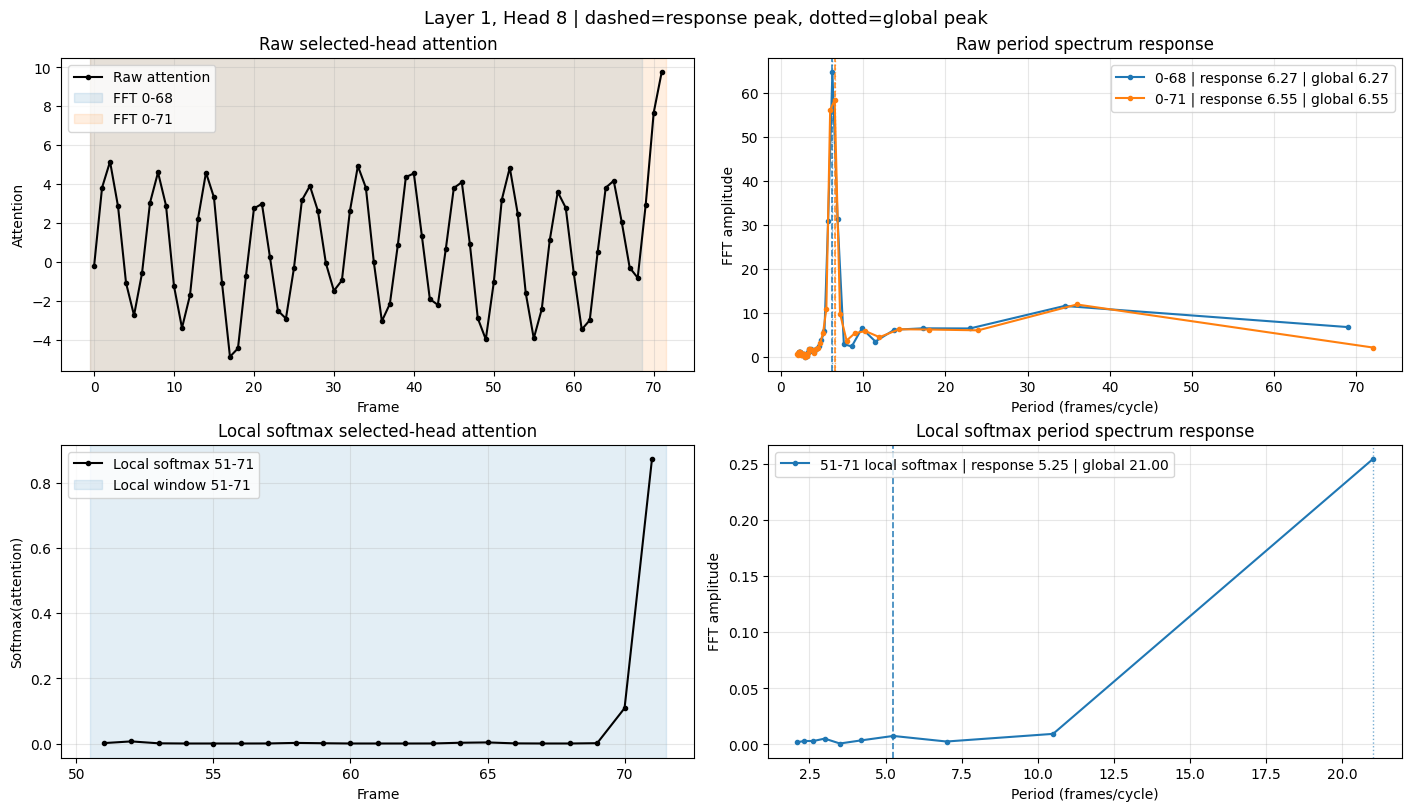

In [ ]:
attention, frame_idx, attn_path = load_attention(ATTN_DIR, LAYER, HEAD)
softmax_attention, softmax_window = local_softmax_1d(
    attention,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_END,
    temperature=SOFTMAX_TEMPERATURE,
)

raw_results = analyze_fft_ranges(attention, FFT_RANGES)
softmax_results = analyze_fft_ranges(softmax_window, SOFTMAX_FFT_RANGES)

print(f"Loaded {attn_path}: layer={LAYER}, head={HEAD}, frames={attention.size}")
print_attention_diagnostics(
    attention,
    softmax_attention,
    softmax_window,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_LABEL,
)
print_results("Raw attention", raw_results)
print_results("Local softmax attention", softmax_results)

plot_attention_and_spectra(
    frame_idx,
    attention,
    softmax_attention,
    raw_results,
    softmax_results,
    SOFTMAX_WINDOW_START,
    SOFTMAX_WINDOW_END,
    SOFTMAX_WINDOW_LABEL,
)
